# Subject-Only Keypoint MoSeq Timeline With Trial Structure

This notebook:

- uses only `subject` recordings from Keypoint MoSeq
- matches each subject to its manual behavior CSV
- extracts trial phases from `*_Introduced` and `*_Removed`
- extracts in-bout behaviors like `Investigation`
- overlays trial structure and investigation periods on the syllable timeline


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns

plt.rcParams["figure.dpi"] = 120
sns.set_context("talk")
sns.set_style("whitegrid")

## Paths

In [2]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "Pose_Tracking":
    POSE_TRACKING_DIR = PROJECT_ROOT
else:
    POSE_TRACKING_DIR = PROJECT_ROOT / "Pose_Tracking"

project_dir = POSE_TRACKING_DIR / "keypoint_moseq_project_home_cage"
model_name = "2026_04_28-12_42_32"
syllable_frames_path = project_dir / model_name / "syllable_frames.csv"

behavior_csv_dir = Path(r"C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Home_Cage\csvs")

syllable_frames_path, behavior_csv_dir

(WindowsPath('c:/Users/alber/OneDrive/Documents/GitHub/Fiber_Photometry_revisions/Pose_Tracking/keypoint_moseq_project_home_cage/2026_04_28-12_42_32/syllable_frames.csv'),
 WindowsPath('C:/Users/alber/OneDrive/Desktop/PC_Lab/Photometry/Pilot_2/Combined_Cohorts/Home_Cage/csvs'))

## Load Subject-Only Syllable Frames

In [3]:
df = pd.read_csv(syllable_frames_path)
df_subject = df[df["track_name"] == "subject"].copy()
df_subject = df_subject.sort_values(["recording_name", "frame_index"]).reset_index(drop=True)
df_subject.head()

,recording_name,frame_index,syllable,time_s,centroid_x,centroid_y,heading,subject_name,trial_name,track_name,source_h5,n_frames,fps,bout_name,bout_start_s,bout_end_s
0,n5_subject,0,33,0.0,149.242960,308.021917,-2.874991,n5,n5-240823-085032,subject,C:\Users\alber\OneDrive\Desktop\PC_Lab\Photome...,17728,10.0,NaN,NaN,NaN
1,n5_subject,1,33,0.1,148.684429,307.693357,-2.901321,n5,n5-240823-085032,subject,C:\Users\alber\OneDrive\Desktop\PC_Lab\Photome...,17728,10.0,NaN,NaN,NaN
2,n5_subject,2,33,0.2,147.290390,308.486806,0.912420,n5,n5-240823-085032,subject,C:\Users\alber\OneDrive\Desktop\PC_Lab\Photome...,17728,10.0,NaN,NaN,NaN
3,n5_subject,3,33,0.3,147.517330,307.442960,-2.163721,n5,n5-240823-085032,subject,C:\Users\alber\OneDrive\Desktop\PC_Lab\Photome...,17728,10.0,NaN,NaN,NaN
4,n5_subject,4,33,0.4,146.841850,307.623480,-0.748182,n5,n5-240823-085032,subject,C:\Users\alber\OneDrive\Desktop\PC_Lab\Photome...,17728,10.0,NaN,NaN,NaN


## Helpers

In [4]:
BOUT_DEFINITIONS = [
    {"prefix": "Short_Term", "introduced": "Short_Term_Introduced", "removed": "Short_Term_Removed"},
    {"prefix": "Long_Term",  "introduced": "Long_Term_Introduced",  "removed": "Long_Term_Removed"},
    {"prefix": "Novel",      "introduced": "Novel_Introduced",      "removed": "Novel_Removed"},
]


def subset_subject_recording(df, recording_name=None, subject_name=None):
    out = df.copy()
    if recording_name is not None:
        out = out[out["recording_name"] == recording_name]
    if subject_name is not None:
        out = out[out["subject_name"] == subject_name]
    return out.sort_values(["recording_name", "frame_index"]).reset_index(drop=True)


def match_behavior_csv(subject_name, csv_dir):
    candidates = sorted(csv_dir.glob(f"{subject_name}-*.csv"))
    if not candidates:
        raise FileNotFoundError(f"No behavior CSV found for subject {subject_name} in {csv_dir}")
    return candidates[0]


def load_behavior_csv(csv_path):
    beh = pd.read_csv(csv_path)
    beh["Start (s)"] = pd.to_numeric(beh["Start (s)"], errors="coerce")
    beh["Stop (s)"] = pd.to_numeric(beh["Stop (s)"], errors="coerce")
    beh = beh[beh["Subject"] == "Subject"].copy()
    return beh


def extract_bouts_and_events(beh_df, bout_definitions, first_only=False):
    bouts = {}
    for bd in bout_definitions:
        starts = beh_df.loc[beh_df["Behavior"] == bd["introduced"], "Start (s)"].sort_values().to_numpy()
        ends = beh_df.loc[beh_df["Behavior"] == bd["removed"], "Start (s)"].sort_values().to_numpy()
        n = min(len(starts), len(ends))
        for i in range(n):
            bouts[f"{bd['prefix']}-{i+1}"] = (float(starts[i]), float(ends[i]))

    boundary_behaviors = {bd["introduced"] for bd in bout_definitions} | {bd["removed"] for bd in bout_definitions}
    rows = []
    for bout_label, (start, end) in bouts.items():
        subset = beh_df[(~beh_df["Behavior"].isin(boundary_behaviors)) & (beh_df["Start (s)"] >= start) & (beh_df["Stop (s)"] <= end)].sort_values("Start (s)")
        if first_only:
            for behavior_type, grp in subset.groupby("Behavior"):
                r = grp.iloc[0]
                rows.append({
                    "Bout": bout_label,
                    "Behavior": behavior_type,
                    "Event_Start": float(r["Start (s)"]),
                    "Event_End": float(r["Stop (s)"]),
                    "Duration (s)": float(r["Stop (s)"] - r["Start (s)"]),
                })
        else:
            for _, r in subset.iterrows():
                rows.append({
                    "Bout": bout_label,
                    "Behavior": r["Behavior"],
                    "Event_Start": float(r["Start (s)"]),
                    "Event_End": float(r["Stop (s)"]),
                    "Duration (s)": float(r["Stop (s)"] - r["Start (s)"]),
                })

    return bouts, pd.DataFrame(rows)


def extract_syllable_transitions(df):
    df = df.sort_values(["recording_name", "frame_index"]).reset_index(drop=True)
    parts = []
    for recording_name, rec in df.groupby("recording_name", sort=False):
        rec = rec.sort_values("frame_index").reset_index(drop=True)
        if len(rec) < 2:
            continue
        prev = rec.iloc[:-1].reset_index(drop=True)
        curr = rec.iloc[1:].reset_index(drop=True)
        consecutive = (curr["frame_index"].to_numpy() - prev["frame_index"].to_numpy()) == 1
        if not consecutive.any():
            continue
        transitions = pd.DataFrame({
            "recording_name": recording_name,
            "subject_name": prev.loc[consecutive, "subject_name"].to_numpy(),
            "from_frame": prev.loc[consecutive, "frame_index"].to_numpy(),
            "to_frame": curr.loc[consecutive, "frame_index"].to_numpy(),
            "time_s": curr.loc[consecutive, "time_s"].to_numpy(),
            "from_syllable": prev.loc[consecutive, "syllable"].to_numpy(),
            "to_syllable": curr.loc[consecutive, "syllable"].to_numpy(),
        })
        transitions["transition_label"] = transitions["from_syllable"].astype(str) + "->" + transitions["to_syllable"].astype(str)
        transitions["changed"] = transitions["from_syllable"] != transitions["to_syllable"]
        parts.append(transitions)
    if not parts:
        return pd.DataFrame(columns=["recording_name", "subject_name", "from_frame", "to_frame", "time_s", "from_syllable", "to_syllable", "transition_label", "changed"])
    return pd.concat(parts, ignore_index=True)


def make_transition_matrix(transitions_df, normalize=True):
    matrix = pd.crosstab(transitions_df["from_syllable"], transitions_df["to_syllable"])
    matrix = matrix.sort_index().sort_index(axis=1)
    if normalize:
        matrix = matrix.div(matrix.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)
    return matrix


def plot_subject_timeline_with_structure(df_rec, bouts, events_df, behavior_name="Investigation", title=None, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(16, 5))

    ordered = df_rec.sort_values("frame_index").reset_index(drop=True)
    ax.scatter(
        ordered["time_s"],
        ordered["syllable"],
        c=ordered["syllable"],
        cmap="tab20",
        s=9,
        linewidths=0,
        alpha=0.9,
        zorder=3,
    )

    bout_palette = {
        "Short_Term": "#dceefb",
        "Novel": "#fde2e4",
        "Long_Term": "#e4f8e0",
    }
    for bout_label, (start, end) in bouts.items():
        prefix = bout_label.split("-")[0]
        color = bout_palette.get(prefix, "#eeeeee")
        ax.axvspan(start, end, color=color, alpha=0.55, zorder=0)
        ax.text((start + end) / 2, ax.get_ylim()[1], bout_label, ha="center", va="bottom", fontsize=10)

    if not events_df.empty:
        beh = events_df[events_df["Behavior"] == behavior_name].copy()
        for _, row in beh.iterrows():
            ax.axvspan(row["Event_Start"], row["Event_End"], color="gold", alpha=0.35, zorder=1)

    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Syllable")
    ax.set_title(title or f"Subject syllables with {behavior_name} overlay")

    legend_handles = [
        mpatches.Patch(color="#dceefb", alpha=0.55, label="Short_Term bout"),
        mpatches.Patch(color="#fde2e4", alpha=0.55, label="Novel bout"),
        mpatches.Patch(color="#e4f8e0", alpha=0.55, label="Long_Term bout"),
        mpatches.Patch(color="gold", alpha=0.35, label=behavior_name),
    ]
    ax.legend(handles=legend_handles, loc="upper right", frameon=True)
    return ax


def plot_transition_timeline(transitions_df, top_n=15, changed_only=True, title=None, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(16, 6))
    data = transitions_df.copy()
    if changed_only:
        data = data[data["changed"]]
    top_labels = data["transition_label"].value_counts().head(top_n).index.tolist()
    data = data[data["transition_label"].isin(top_labels)].copy()
    label_order = list(reversed(top_labels))
    y_map = {label: idx for idx, label in enumerate(label_order)}
    ax.scatter(data["time_s"], data["transition_label"].map(y_map), c=data["from_syllable"], cmap="tab20", s=11, linewidths=0, alpha=0.85)
    ax.set_yticks(range(len(label_order)))
    ax.set_yticklabels(label_order)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Transition")
    ax.set_title(title or "Subject syllable transitions over time")
    return ax


## Choose a Subject Recording

Pick one `recording_name` from the subject-only table, for example `n5_subject`.

In [5]:
sorted(df_subject["recording_name"].unique())[:15]

['n5_subject',
 'n6_subject',
 'n7_subject',
 'nn1_subject',
 'nn2_subject',
 'nn3_subject',
 'nn4_subject',
 'nn5_subject',
 'nn6_subject',
 'nn7_subject',
 'nn8_subject',
 'p1_subject',
 'p2_subject',
 'p3_subject',
 'p5_subject']

In [6]:
recording_name = "n5_subject"

df_rec = subset_subject_recording(df_subject, recording_name=recording_name)
subject_name = df_rec["subject_name"].iloc[0]
behavior_csv_path = match_behavior_csv(subject_name, behavior_csv_dir)
beh_df = load_behavior_csv(behavior_csv_path)
bouts, events_df = extract_bouts_and_events(beh_df, BOUT_DEFINITIONS, first_only=False)
transitions = extract_syllable_transitions(df_rec)

behavior_csv_path

WindowsPath('C:/Users/alber/OneDrive/Desktop/PC_Lab/Photometry/Pilot_2/Combined_Cohorts/Home_Cage/csvs/n5-240823-085032.csv')

## Subject Syllables With Trial Structure Overlay

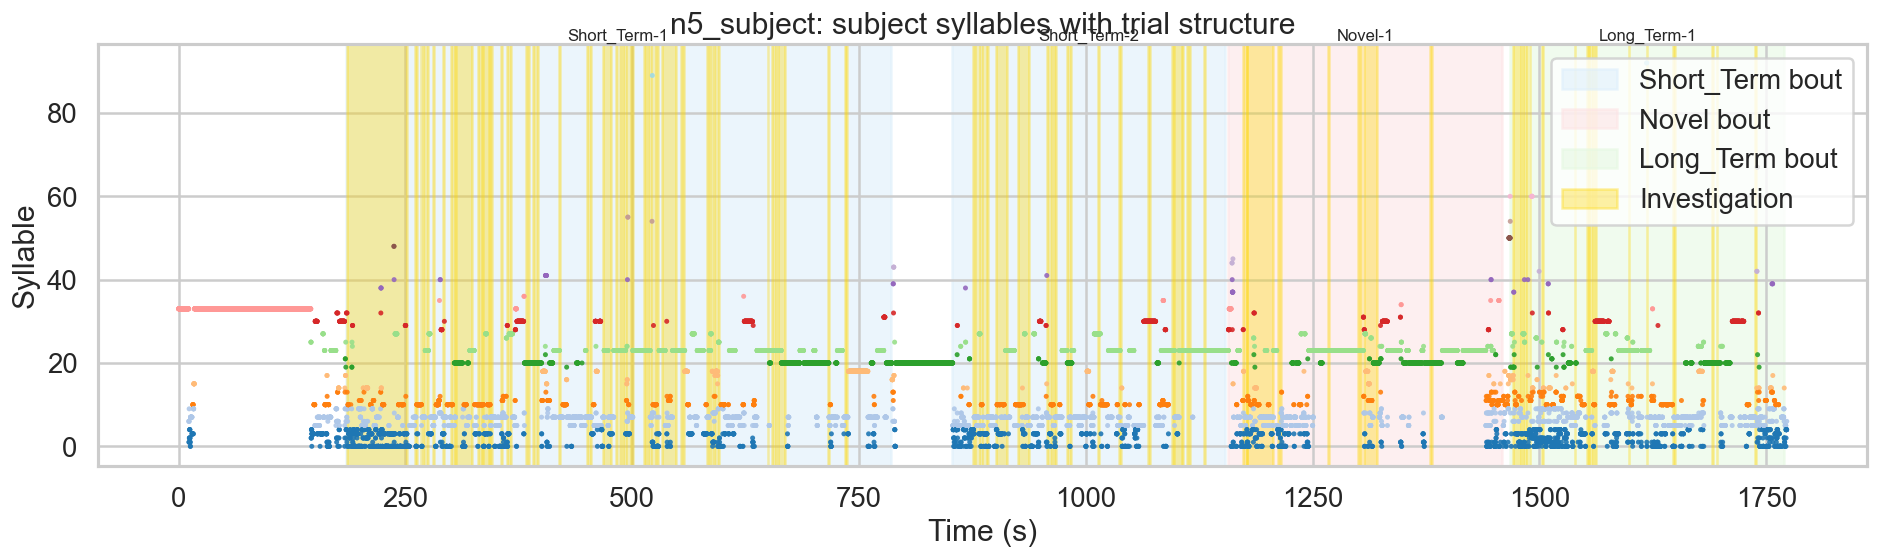

In [7]:
fig, ax = plt.subplots(figsize=(16, 5))
plot_subject_timeline_with_structure(
    df_rec,
    bouts,
    events_df,
    behavior_name="Investigation",
    title=f"{recording_name}: subject syllables with trial structure",
    ax=ax,
)
plt.tight_layout()

## Subject Transition Timeline

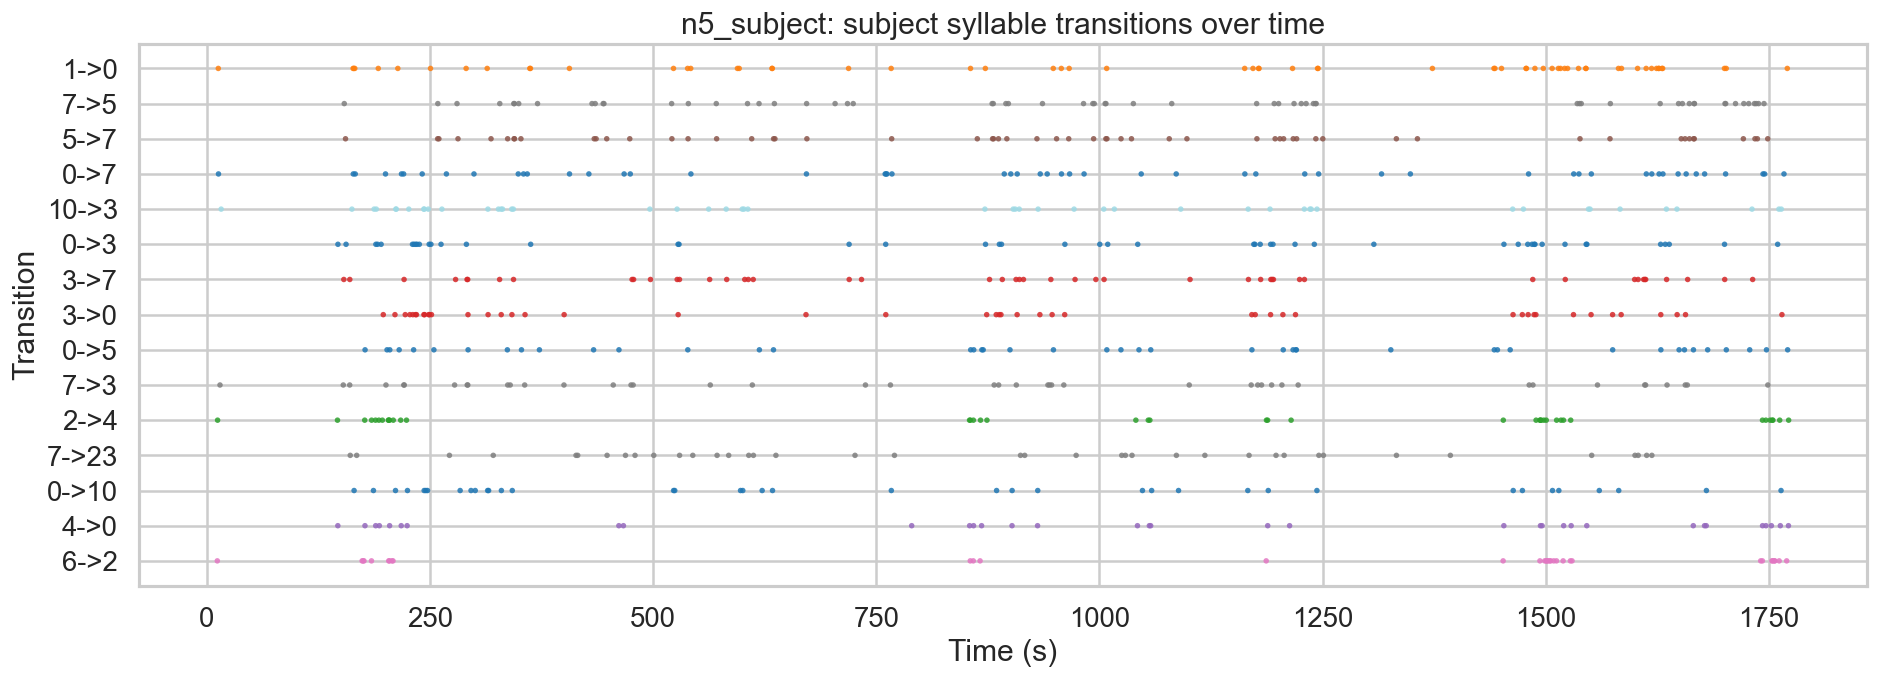

In [8]:
fig, ax = plt.subplots(figsize=(16, 6))
plot_transition_timeline(
    transitions,
    top_n=15,
    changed_only=True,
    title=f"{recording_name}: subject syllable transitions over time",
    ax=ax,
)
plt.tight_layout()

## Transition Probability Matrix

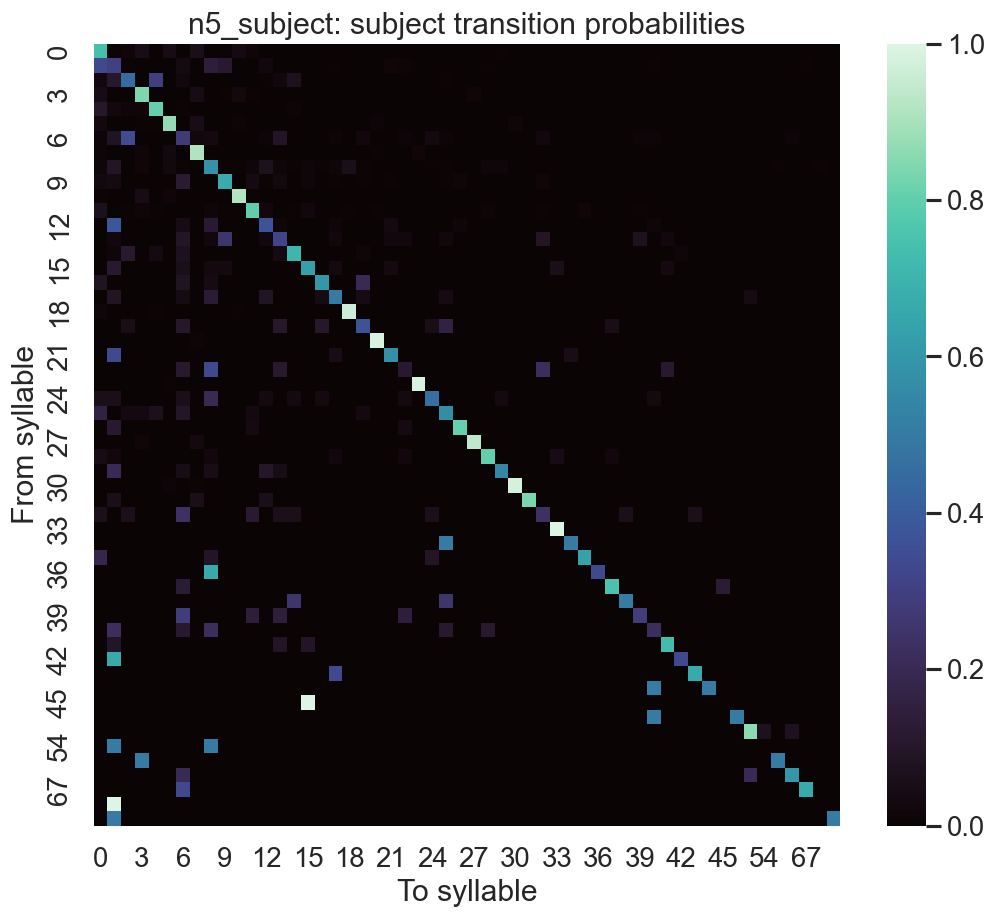

In [9]:
transition_matrix = make_transition_matrix(transitions, normalize=True)
plt.figure(figsize=(9, 8))
sns.heatmap(transition_matrix, cmap="mako")
plt.xlabel("To syllable")
plt.ylabel("From syllable")
plt.title(f"{recording_name}: subject transition probabilities")
plt.tight_layout()

## Investigation Events Within Each Bout

In [10]:
events_df[events_df["Behavior"] == "Investigation"].head(20)

,Bout,Behavior,Event_Start,Event_End,Duration (s)
0,Short_Term-1,Investigation,185.3,251.399,66.099
2,Short_Term-1,Investigation,260.6,262.700,2.100
4,Short_Term-1,Investigation,267.1,267.800,0.700
5,Short_Term-1,Investigation,269.2,274.600,5.400
6,Short_Term-1,Investigation,280.2,281.900,1.700
7,Short_Term-1,Investigation,291.4,292.200,0.800
9,Short_Term-1,Investigation,300.4,305.100,4.700
10,Short_Term-1,Investigation,305.9,323.999,18.099
12,Short_Term-1,Investigation,330.1,334.299,4.199
14,Short_Term-1,Investigation,336.1,341.999,5.899
